 # Mode-connectivity in loss landscape

Assume that we have a class of models $\mathcal M$, parametrized by parameters $w \in \mathbb R^n$. Then the paper posits that two neural networks parametrised with $w_1$ and $w_2$, which both are local minimas of the loss function, can be connected by a simple path, which maintain the same minimal loss.

In the paper, the path is parametrized as a chain of two straight lines that both connect to a third parameter set $\theta$:

$$
\phi_{\theta}(t)=
\begin{cases}
2\left(t\theta + (0.5 - t)w_1\right), & 0 \le t \le 0.5 \\
2\left((t - 0.5)w_2 + (1 - t)\theta\right), & 0.5 \le t \le 1
\end{cases}
$$


Or as I have done in this implementation, the path is parameterized as a bezier curve connecting the start and end points:

$$
\phi_{\theta}(t) = (1-t)^2w_1 + 2t(1-t)\theta + t^2w_2
$$

Given that the two end-point models parametrized by $w_1$ and $w_2$ has been trained and reached local minimas, the curve-model parametrized by $\phi_{\theta}(t)$ is trained by minimizing the expectation over a uniform distribution on the curve:

$$
\ell(\theta) = \underset{t\sim U(0,1)}{\mathbb E}[\mathcal L(\phi_{\theta}(t))]
$$

where $\mathcal L$ is the loss at a single model instance.

First some imports and initializations:

In [1]:
from models import CIFAR10ConvNet
import torch
from scheduler import make_diy_scheduler
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from train import train
from curve_model import Curve
import os
import matplotlib.pyplot as plt
import torchmetrics
from curve_plots import plot_Curve_losslandscape, bezier_plot
import pandas as pd

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
torch.manual_seed(0)
root = ".."
datafolder = f"{root}/data"
base_directory = f"{root}/experiments/results_notebook_CIFAR"

In [ ]:
MODEL = CIFAR10ConvNet
model_kargs = {"dropout": 0.5}
loss_fn = torch.nn.CrossEntropyLoss(weight=None, size_average=None, ignore_index=-100, reduce=None, reduction='mean', label_smoothing=0.0)
batch_size = 256

dataset = "CIFAR10"
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.CIFAR10(root=f'{datafolder}/train', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root=f'{datafolder}/test', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
train_loader = DataLoader(train_dataset, batch_size=batch_size)

os.makedirs(f"{base_directory}/models", exist_ok=True)
os.makedirs(f"{base_directory}/figures", exist_ok=True)


/Users/simondanieleiriksson/Documents/GitHub/mode-connectivity/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# Train end point models
The first step is to train the two models $w_1$ and $w_2$. Here we call them `model_start` and `model_end`. Note that it takes around 10 minutes to train each of the models on a macbook m2, so if you don't have patience for that, you can set the variable `retrain=False`, and a pretrained model is loaded from the repo.

epoch = 5 	train loss: 1.36264, test loss: 1.23696, test accuracy: 56.15, lr: 2.000000e-03
epoch = 10 	train loss: 1.09127, test loss: 0.97320, test accuracy: 65.80, lr: 2.000000e-03
epoch = 15 	train loss: 0.94787, test loss: 0.85879, test accuracy: 70.59, lr: 2.000000e-03
epoch = 20 	train loss: 0.86296, test loss: 0.78267, test accuracy: 73.09, lr: 2.000000e-03
epoch = 25 	train loss: 0.79923, test loss: 0.72866, test accuracy: 75.20, lr: 2.000000e-03
epoch = 30 	train loss: 0.76573, test loss: 0.75264, test accuracy: 74.23, lr: 2.000000e-03
epoch = 35 	train loss: 0.73163, test loss: 0.68605, test accuracy: 76.83, lr: 2.000000e-03
epoch = 40 	train loss: 0.69499, test loss: 0.68156, test accuracy: 77.39, lr: 2.000000e-03
epoch = 45 	train loss: 0.67578, test loss: 0.65588, test accuracy: 78.01, lr: 2.000000e-03
epoch = 50 	train loss: 0.66051, test loss: 0.68788, test accuracy: 76.83, lr: 2.000000e-03
epoch = 55 	train loss: 0.64714, test loss: 0.65633, test accuracy: 77.74, lr: 2.

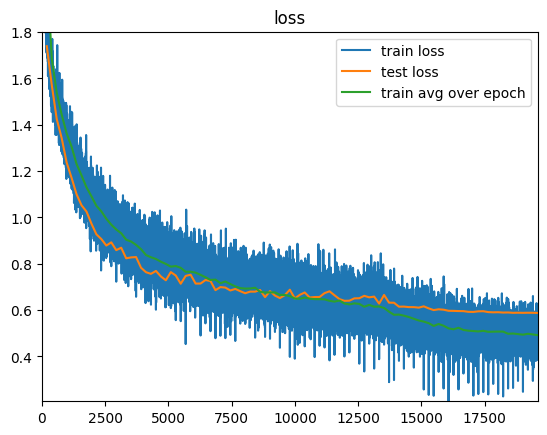

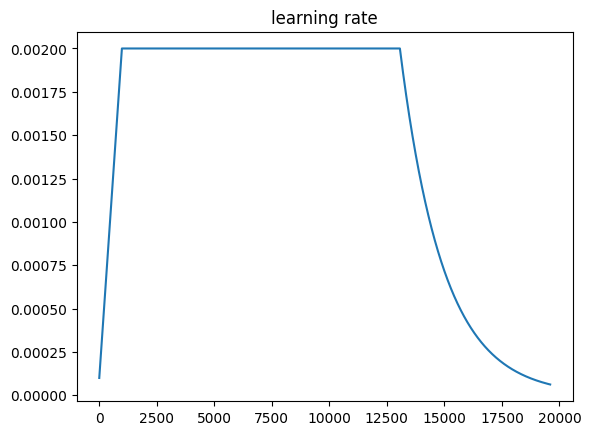

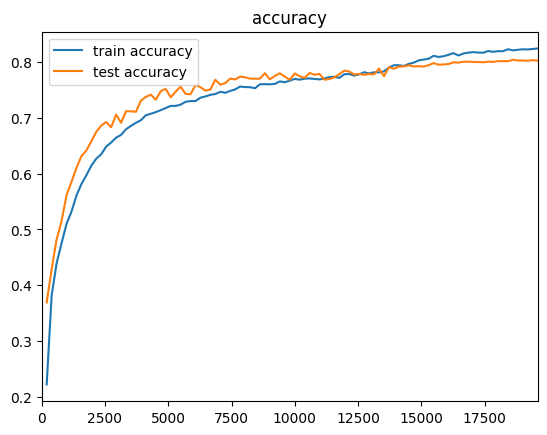

In [3]:

retrain=True
if retrain:
    model_lr_start = torch.tensor(1e-4)
    model_lr_end = torch.tensor(2e-3)
    model_epochs = 100

    total_iter = model_epochs*train_loader.__len__()

    model_start = MODEL(**model_kargs).to(device)
    optimizer_start = torch.optim.Adam(params=model_start.parameters(), lr=model_lr_start.clone())
    scheduler_start = make_diy_scheduler(optimizer_start, 
                                             train_num_steps=total_iter, 
                                             lr_start_warmup=model_lr_start.clone(), 
                                             lr=model_lr_end.clone(), 
                                             lr_warmup_steps=5*train_loader.__len__(), 
                                             lr_finetune_halftime=total_iter // (5*3), 
                                             lr_finetune_steps=total_iter // 3
            )
    model_start, all_train_losses, lrs, epoch_train_losses, test_losses, epoch_train_accuracy, plots = train(model_start, 
                                                train_loader=train_loader, 
                                                test_loader=test_loader, 
                                                optimizer=optimizer_start, 
                                                scheduler=scheduler_start, 
                                                epochs=model_epochs, loss_fn=loss_fn, device=device, 
                                                plot=True, plotpath=f"{base_directory}/start_model/figures",
                                                verbose=True, print_every_n_epoch=5
                                                )
    torch.save(model_start, f"{base_directory}/models/model_start_{MODEL.__name__}_{dataset}.pth")
    for k in plots.keys():
        display(plots[k][0])
else:
    model_start = torch.load(f"{base_directory}/models/model_start_{MODEL.__name__}_{dataset}.pth", map_location=torch.device(device), weights_only=False)

And the second model `model_end`:

epoch = 5 	train loss: 1.40304, test loss: 1.27980, test accuracy: 53.39, lr: 2.000000e-03
epoch = 10 	train loss: 1.09548, test loss: 0.96023, test accuracy: 65.70, lr: 2.000000e-03
epoch = 15 	train loss: 0.93408, test loss: 0.85403, test accuracy: 70.28, lr: 2.000000e-03
epoch = 20 	train loss: 0.84885, test loss: 0.76703, test accuracy: 73.52, lr: 2.000000e-03
epoch = 25 	train loss: 0.79300, test loss: 0.73559, test accuracy: 74.69, lr: 2.000000e-03
epoch = 30 	train loss: 0.74879, test loss: 0.72628, test accuracy: 74.95, lr: 2.000000e-03
epoch = 35 	train loss: 0.72184, test loss: 0.71185, test accuracy: 75.77, lr: 2.000000e-03
epoch = 40 	train loss: 0.69970, test loss: 0.71180, test accuracy: 75.52, lr: 2.000000e-03
epoch = 45 	train loss: 0.67868, test loss: 0.67331, test accuracy: 76.91, lr: 2.000000e-03
epoch = 50 	train loss: 0.66500, test loss: 0.67480, test accuracy: 76.69, lr: 2.000000e-03
epoch = 55 	train loss: 0.65032, test loss: 0.65642, test accuracy: 77.44, lr: 2.

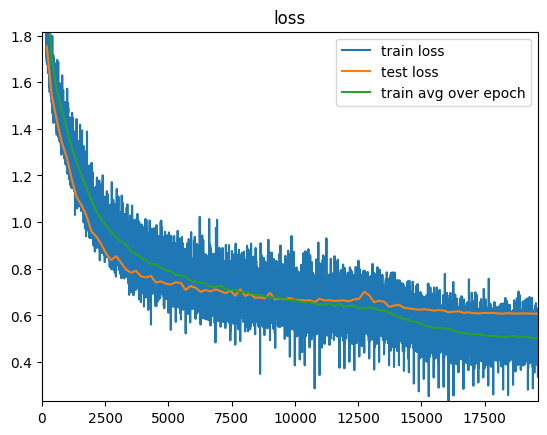

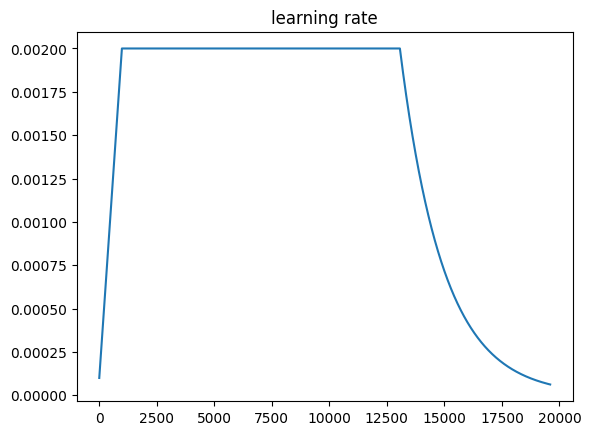

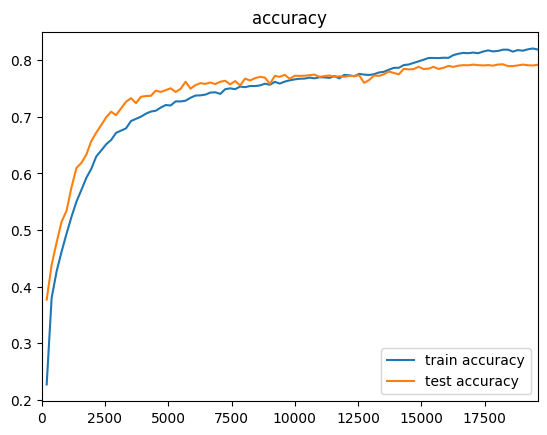

In [4]:
if retrain:
    model_lr_start = torch.tensor(1e-4)
    model_lr_end = torch.tensor(2e-3)
    model_epochs = 100

    total_iter = model_epochs*train_loader.__len__()

    model_end = MODEL(**model_kargs).to(device)
    optimizer_end = torch.optim.Adam(params=model_end.parameters(), lr=model_lr_start.clone())
    scheduler_end = make_diy_scheduler(optimizer_end, 
                                             train_num_steps=total_iter, 
                                             lr_start_warmup=model_lr_start.clone(), 
                                             lr=model_lr_end.clone(), 
                                             lr_warmup_steps=5*train_loader.__len__(), 
                                             lr_finetune_halftime=total_iter // (5*3), 
                                             lr_finetune_steps=total_iter // 3
            )
    model_end, all_train_losses, lrs, epoch_train_losses, test_losses, epoch_train_accuracy, plots = train(model_end, 
                                                train_loader=train_loader, 
                                                test_loader=test_loader, 
                                                optimizer=optimizer_end, 
                                                scheduler=scheduler_end, 
                                                epochs=model_epochs, loss_fn=loss_fn, device=device, 
                                                plot=True, plotpath=f"{base_directory}/end_model/figures",
                                                verbose=True, print_every_n_epoch=5
                                                )
    torch.save(model_end, f"{base_directory}/models/model_end_{MODEL.__name__}_{dataset}.pth")
    for k in plots.keys():
        display(plots[k][0])
else:
    model_end = torch.load(f"{base_directory}/models/model_end_{MODEL.__name__}_{dataset}.pth", map_location=torch.device(device), weights_only=False)

# Training the curve model

In order to train the curve model, we first have to define the bezier curve 
$$
\phi_{\theta}(t) = (1-t)^2w_1 + 2t(1-t)\theta + t^2w_2.
$$

This mapping takes each of the endpoint models ($w_1$, $w_2$), a timestep $t\in [0,1]$, and a third model ($\theta$) -- which is the one we will be training now -- and returns a fourth model ($\phi$).

In [5]:
def curve_fn(param_start, param_end, param_theta, t):
    return param_start * (1-t)**2 + param_end * t**2 + param_theta * 2*t*(1-t)

Using PyTorch reparameterizing functionality, this mapping is used in the `Curve` class. By sampling a $t\in [0,1]$, we can then train $\theta$, to minimize the loss generated by the model $\phi_\theta(t)$.

epoch = 5 	train loss: 1.17061, test loss: 1.16953, test accuracy: 59.66, lr: 1.000000e-01
epoch = 10 	train loss: 0.92917, test loss: 0.87661, test accuracy: 70.28, lr: 1.000000e-01
epoch = 15 	train loss: 0.76058, test loss: 0.82764, test accuracy: 71.36, lr: 1.000000e-01
epoch = 20 	train loss: 0.72864, test loss: 0.89234, test accuracy: 69.60, lr: 1.000000e-01
epoch = 25 	train loss: 0.66581, test loss: 0.76688, test accuracy: 74.14, lr: 1.000000e-01
epoch = 30 	train loss: 0.64305, test loss: 0.72425, test accuracy: 75.10, lr: 1.000000e-01
epoch = 35 	train loss: 0.62255, test loss: 0.71827, test accuracy: 75.75, lr: 1.000000e-01
epoch = 40 	train loss: 0.63745, test loss: 0.76097, test accuracy: 73.94, lr: 1.000000e-01
epoch = 45 	train loss: 0.59884, test loss: 0.71721, test accuracy: 75.74, lr: 1.000000e-01
epoch = 50 	train loss: 0.59199, test loss: 0.75106, test accuracy: 74.41, lr: 1.000000e-01
epoch = 55 	train loss: 0.59119, test loss: 0.73681, test accuracy: 74.94, lr: 1.

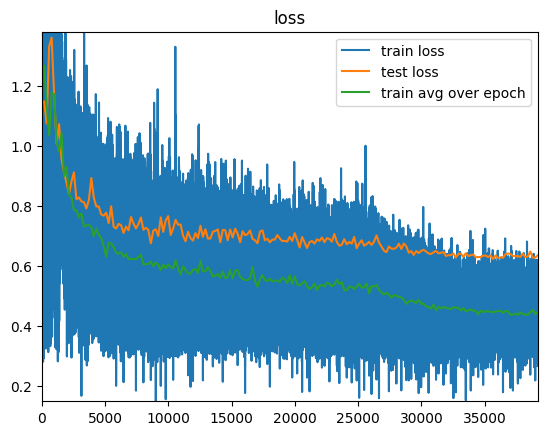

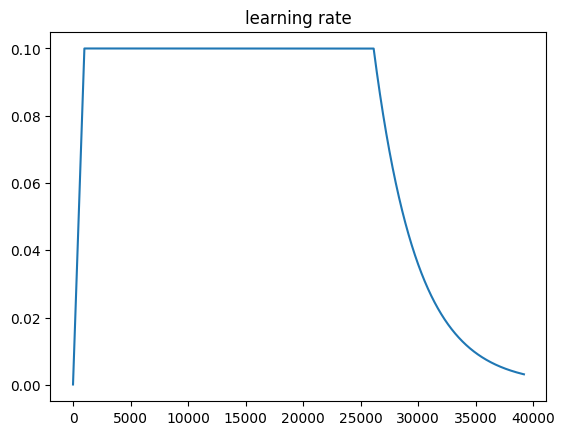

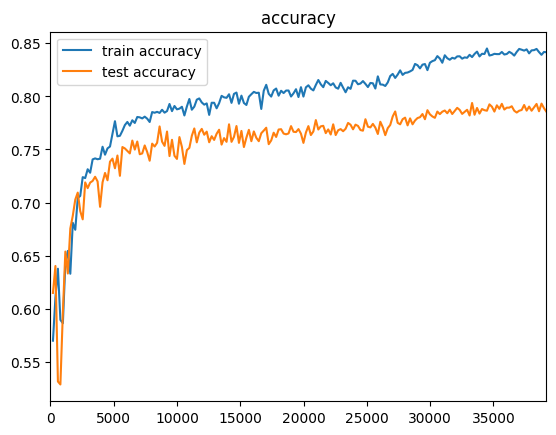

In [6]:
retrain_curve = True
curve_epochs= 200
curve_lr_start = torch.tensor(1e-4)
curve_lr_end = torch.tensor(1e-1)
curve_optimizer = "SGD"
total_iter = curve_epochs*train_loader.__len__()


if retrain_curve:
    total_iter = curve_epochs*train_loader.__len__()
    curve = Curve(model_start=model_start, model_end=model_end, curve_fn=curve_fn, device=device)
    gamma = ((curve_lr_end.log()-curve_lr_start.log())/(curve_epochs*train_loader.__len__())).exp()

    optimizer = torch.optim.SGD(params=curve.model_theta.parameters(), lr=curve_lr_start, momentum=0.9)

    scheduler = make_diy_scheduler(optimizer, 
                                            train_num_steps=total_iter, 
                                            lr_start_warmup=curve_lr_start.clone(), 
                                            lr=curve_lr_end.clone(), 
                                            lr_warmup_steps=5*train_loader.__len__(), 
                                            lr_finetune_halftime=total_iter // (5*3), 
                                            lr_finetune_steps=total_iter // 3
        )
            

    curve, all_train_losses, lrs, epoch_train_losses, test_losses, epoch_train_accuracy, plots = train(curve, 
                                                                        train_loader=train_loader, 
                                                                        test_loader=test_loader, 
                                                                        optimizer=optimizer, 
                                                                        scheduler=scheduler, 
                                                                        epochs=curve_epochs,
                                                                        loss_fn=loss_fn, 
                                                                        device=device, 
                                                                        plot=True, 
                                                                        plotpath=f"{base_directory}/curve_model/figures", 
                                                                        #plotname=f"curvefitting_{MODEL.__name__}_{dataset}", 
                                                                        modeltype="curve", 
                                                                        verbose=True, print_every_n_epoch=5)
    torch.save(curve.model_theta, f"{base_directory}/models/curve.model_theta_{MODEL.__name__}_{dataset}.pth")
    for k in plots.keys():
        display(plots[k][0])
else:
    curve = Curve(model_start=model_start, model_end=model_end, curve_fn=curve_fn, device=device)
    curve.model_theta = torch.load(f"{base_directory}/models/curve.model_theta_{MODEL.__name__}_{dataset}.pth", map_location=torch.device(device), weights_only=False)
    

As can be seen in the loss plot, there is much more variance in the loss for the $\phi$ models, then there were when training the endpoint models $w_1$ and $w_2$. This is due to the stochasticity induced by $t$. 


Now for a plot of the loss landscape in the 2d subspace spanned by the three models: 


begin loss landscape plot
begin calculation of mesh for loss landscape plot
finished loss landscape plotest_loss = 316.68555673828126



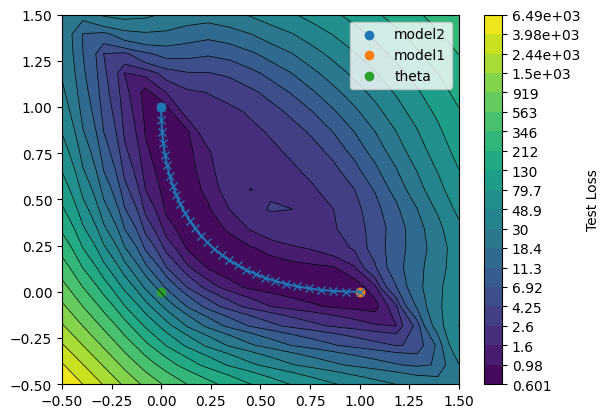

In [12]:
fig, ax = plot_Curve_losslandscape(curve, device, f"{base_directory}/figures", test_loader, N_points=20, loss_fn=loss_fn, recalc_mesh=True, N_bezierpoints=30)
fig.savefig(f"{base_directory}/figures/loss_landscape.png")
plt.show(fig)

# Performance along the curve

Given that $\theta$ is now fixed, the performance along the curve can be investigated. In the follwong plot, several performance measures are plotted as function of time $t$. 

First the Cross Entropy, which is also the loss used for training. Note that the Cross Entropy loss is a slighty bit higher in the inner part of the curve, than at the endpoints. That is reasonable, since the endpoints have been trained freely, whereas the curve is optimized along its full length. 

However, the difference between the inner parts of the curve and the endpoints is not very large compared to the difference between the endpoints. With regards to the accuracy, the models sampled along the curve are actually better than the ones at the endpoints.

In [8]:
metrics_dict = {
    "Cross Entropy": lambda pred_probs, target: torch.nn.CrossEntropyLoss(weight=None, size_average=None, ignore_index=-100, reduce=None, reduction='mean', label_smoothing=0.0)(pred_probs.log(), target),
    "Expected Calibration Error": torchmetrics.classification.MulticlassCalibrationError(num_classes=10, n_bins=25).to(device),
    "Accuracy": lambda pred_probs, target: torchmetrics.functional.classification.accuracy(preds=pred_probs, target=target, task="multiclass", num_classes=10).to(device),
    "AUROC": lambda pred_probs, target: torchmetrics.functional.classification.auroc(preds=pred_probs, target=target.to(torch.long), task="multiclass", num_classes=10).to(device)
}



begin evaluation of curve
N_obs = 10000
Cross Entropy start model: 0.5877260565757751
Cross Entropy end mode: 0.6073416471481323
Cross Entropy ensemble: 0.5446681380271912
Expected Calibration Error start model: 0.02317619137465954
Expected Calibration Error end mode: 0.021621543914079666
Expected Calibration Error ensemble: 0.037357114255428314
Accuracy start model: 0.8025000095367432
Accuracy end mode: 0.7918000221252441
Accuracy ensemble: 0.8158000111579895
AUROC start model: 0.9778488278388977
AUROC end mode: 0.9761072397232056
AUROC ensemble: 0.980810284614563
finished evaluation of curve



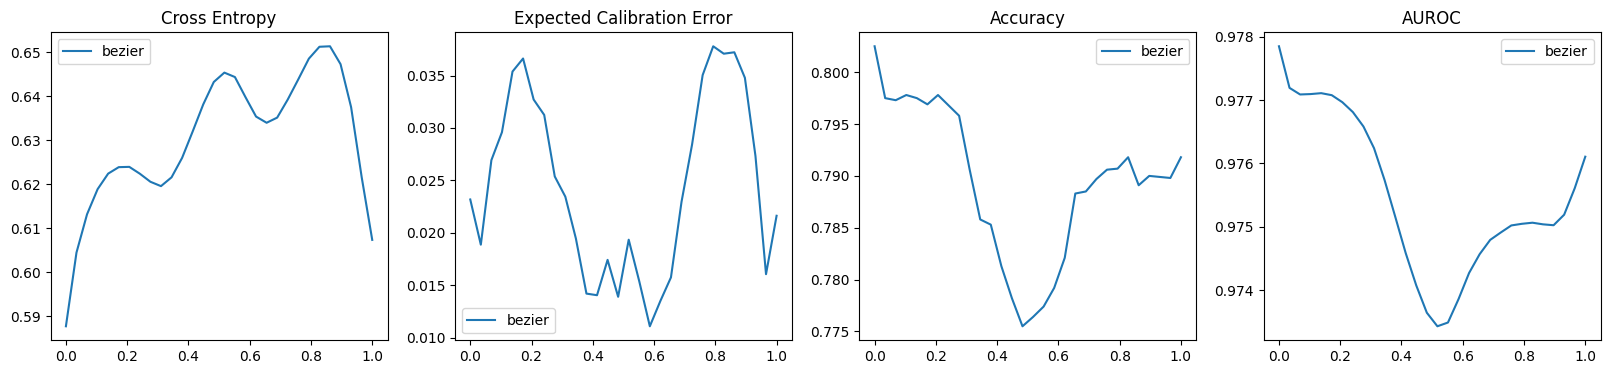

In [9]:
fig, axs, eval_results = bezier_plot(curve, device, test_loader=test_loader, 
                                     plottype="linear", 
                    N_bezierpoints = 30,
                    plot_linear=False, metrics_dict=metrics_dict)
fig.savefig(f"{base_directory}/figures/metric_along_curve.png")
plt.show(fig)

# Ensemble performance

To the question: So what is this good for? 

In general, using an ensemble of models can be used as a rough estimate of the Bayesian posterior distribution. These models should be trained in the same way, but using different random initialisations. However, it takes a lot of compute to train for example 10 independent models. Here, we can use models sampled along the curve, since they are all pretty good as we can see on plots above. 

The performance of the ensemble model is given below, together with the end point models. As can be seen they are indeed a bit better both in terms of CE, Accuracy and AUROC. The ECE is probably higher since the ensemble inevitably gives more conservative predictions than the start and end models - in the sense that the ensemble is less sure about its predictions.

In [10]:
print(pd.DataFrame(eval_results["curve_ensemble_score_dict"]).T.reset_index().rename(columns={"index": "Model"}).to_markdown(index=False))

| Model       |   Cross Entropy |   Expected Calibration Error |   Accuracy |    AUROC |
|:------------|----------------:|-----------------------------:|-----------:|---------:|
| Start model |        0.587726 |                    0.0231762 |     0.8025 | 0.977849 |
| End model   |        0.607342 |                    0.0216215 |     0.7918 | 0.976107 |
| Ensemble    |        0.544668 |                    0.0373571 |     0.8158 | 0.98081  |
